In [1]:
import os, sys
import pybedtools
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np

import itertools
from tqdm import tqdm

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 7

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

In [6]:
path_chromhmm = 'ref/bivalent_chromatin_hesc_10.18632-oncotarget.13746.bed.gz'
path_gtf = 'ref/hg19.refGene.gtf.gz'
path_mane = 'ref/MANE.GRCh38.v1.4.summary.txt.gz'

In [8]:
bedtool_chromhmm = pybedtools.BedTool(path_chromhmm)

In [9]:
# for refgene
df_gtf = pd.read_csv(
    path_gtf,
    sep='\t',
    header=None,
    names=["seqname", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]
)

df_gtf["transcript_id"] = df_gtf["attribute"].str.extract(r'transcript_id "([^"]+)"')
df_gtf["gene_id"] = df_gtf["attribute"].str.extract(r'gene_id "([^"]+)"')

print(df_gtf)

        seqname   source     feature      start        end score strand frame  \
0          chr1  refGene  transcript      11869      14362     .      +     .   
1          chr1  refGene        exon      11869      12227     .      +     .   
2          chr1  refGene        exon      12613      12721     .      +     .   
3          chr1  refGene        exon      13221      14362     .      +     .   
4          chr1  refGene  transcript      11874      14409     .      +     .   
...         ...      ...         ...        ...        ...   ...    ...   ...   
1760954    chr6  refGene        exon  159046735  159046786     .      +     .   
1760955    chr6  refGene        exon  159049440  159049522     .      +     .   
1760956    chr6  refGene        exon  159050762  159050851     .      +     .   
1760957    chr6  refGene        exon  159052355  159052518     .      +     .   
1760958    chr6  refGene        exon  159052842  159056461     .      +     .   

                           

In [10]:
# This section finds the most relevant transcript using MANE annotations
# MANE database is for hg38, but transcript names are consistent between hg19 and hg38 so can be used

df_mane_select = pd.read_csv(
    path_mane, 
    sep='\t'
)

print(df_mane_select)

df_mane_select["RefSeq_nuc_no_exon_or_version"] = df_mane_select["RefSeq_nuc"].str.split('.', expand=True)[0]
mane_refseq_ids = set(df_mane_select["RefSeq_nuc_no_exon_or_version"].dropna().unique())
df_gtf["is_mane"] = df_gtf["transcript_id"].isin(mane_refseq_ids)

print(df_gtf)

canonical_transcripts = []

for gene, group in df_gtf.groupby("gene_id", sort=False):
    # Get all transcript features in this gene
    transcripts = group[group["feature"] == "transcript"]

    # If MANE transcript(s) exist → take them
    mane_trans = transcripts[transcripts["is_mane"]]
    
    if gene == 'PDLIM2':
        # This gene 
        chosen_id = "NM_021630"
    elif not mane_trans.empty:
        # Choose MANE transcript if it exists
        chosen_id = mane_trans.iloc[0]["transcript_id"]
    else:
        # Otherwise, take the first transcript in GTF
        # This is usually the most relevant transcript anyway
        chosen_id = transcripts.iloc[0]["transcript_id"]

    canonical_transcripts.append(chosen_id)

canonical_transcripts = set(canonical_transcripts)

df_gtf_canonical = df_gtf[df_gtf["transcript_id"].isin(canonical_transcripts)].copy()

df_mane_transcripts = df_gtf_canonical.loc[df_gtf_canonical['feature'] == 'transcript']

print(df_mane_transcripts)


           #NCBI_GeneID        Ensembl_Gene     HGNC_ID        symbol  \
0              GeneID:1  ENSG00000121410.13      HGNC:5          A1BG   
1              GeneID:2  ENSG00000175899.15      HGNC:7           A2M   
2              GeneID:9  ENSG00000171428.15   HGNC:7645          NAT1   
3             GeneID:10   ENSG00000156006.5   HGNC:7646          NAT2   
4             GeneID:12  ENSG00000196136.18     HGNC:16      SERPINA3   
...                 ...                 ...         ...           ...   
19399  GeneID:128706666   ENSG00000285508.2         NaN  LOC128706666   
19400  GeneID:128854680   ENSG00000293543.1  HGNC:56772       DUSP13A   
19401  GeneID:130453475   ENSG00000285204.1         NaN       SMN-AS1   
19402  GeneID:131675794  ENSG00000183889.14  HGNC:27893        NPIPA6   
19403  GeneID:131768270   ENSG00000293600.2         NaN  LOC131768270   

                                                    name      RefSeq_nuc  \
0                                 alpha-1-B gly

In [12]:
#BASiCS
#note: mean_1 is for TKO, mean_2 is WT. Same for DKO

path_dko_noise = 'basics/dko_wt_basics_results.csv.gz'
path_tko_noise = 'basics/tko_wt_basics_results.csv.gz'

path_out_dir = 'figures'

df_gene_noise_dko = pd.read_csv(path_dko_noise, index_col=0)
df_gene_noise_tko = pd.read_csv(path_tko_noise, index_col=0)

df_gene_noise = pd.merge(df_gene_noise_dko, df_gene_noise_tko, left_index=True, right_index=True, suffixes=['_dko', '_tko'], how='outer')

print(df_gene_noise)

            MeanOverall_dko  Mean1_dko  Mean2_dko  MeanFC_dko  MeanLog2FC_dko  \
GeneName                                                                        
5S-rRNA-1             0.005      0.005      0.004       1.417           0.503   
7SK-4                 0.006      0.005      0.006       0.934          -0.098   
7SK-5                 0.031      0.036      0.022       1.610           0.687   
A1BG                  0.060      0.071      0.039       1.831           0.872   
A1BG-AS1              0.105      0.124      0.070       1.778           0.830   
...                     ...        ...        ...         ...             ...   
snoU13-297            0.004      0.004      0.004       0.862          -0.214   
snoU13-36             0.003      0.003      0.003       0.988          -0.018   
snoU13-440            0.006      0.006      0.006       0.889          -0.170   
snoU13-66             0.004      0.004      0.003       1.495           0.580   
yR211F11.2            0.004 

In [13]:
# creating promoter region 2kb down/upstream of TSS

extension = 2000

df_promoter = df_mane_transcripts.copy()

df_promoter['length'] = df_promoter['end'] - df_promoter['start']
df_promoter['start_gene'] = df_promoter['start']
df_promoter['end_gene'] = df_promoter['end']

df_promoter['start'] = np.where(
    df_promoter['strand'] == '+',
    df_promoter['start_gene'] - extension, 
    df_promoter['end_gene'] - extension
)

df_promoter['end'] = np.where(
    df_promoter['strand'] == '+',
    df_promoter['start_gene'] + extension, 
    df_promoter['end_gene'] + extension
)

df_promoter.rename(columns={'seqname': 'chrom', 'gene_id': 'gene'}, inplace=True)

df_coord_dict = df_promoter[['chrom', 'start', 'end', 'start_gene', 'end_gene', 'length', 'strand', 'gene']]
coord_dict = {record['gene']:record for record in df_coord_dict.to_dict('records')}

df_bedtool = df_promoter[['chrom', 'start', 'end', 'gene', 'strand']]
bedtool_gtf = pybedtools.BedTool.from_dataframe(df_bedtool)

In [14]:
intersection = bedtool_chromhmm.intersect(bedtool_gtf, wo=True)

In [15]:
count_bivalent = {gene:[] for gene in coord_dict}
count_h3k27me3 = {gene:[] for gene in coord_dict}
count_h3k4me3 = {gene:[] for gene in coord_dict}

for line in intersection:
    
    gene = line[12]
    category = line[3]
    overlap = int(line[-1])
    
    if gene not in count_bivalent:
        continue
    
    if 'Biv' in category:
        count_bivalent[gene].append(overlap)
    elif 'H3K27me3' in category or 'PC' in category:
        count_h3k27me3[gene].append(overlap)
    elif 'H3K4me3' in category or 'Prom' in category:
        count_h3k4me3[gene].append(overlap)
    
bivalent_ratios = {}
bivalent_ratios_list = []

h3k27me3_ratios = {}
h3k27me3_ratios_list = []

h3k4me3_ratios = {}
h3k4me3_ratios_list = []

for gene in count_bivalent:
    
    bivalent_ratios[gene] = sum(count_bivalent[gene]) / extension
    h3k27me3_ratios[gene] = sum(count_h3k27me3[gene]) / extension
    h3k4me3_ratios[gene] = sum(count_h3k4me3[gene]) / extension
    
    bivalent_ratios_list.append(sum(count_bivalent[gene]) / extension)
    h3k27me3_ratios_list.append(sum(count_h3k27me3[gene]) / extension)
    h3k4me3_ratios_list.append(sum(count_h3k4me3[gene]) / extension)

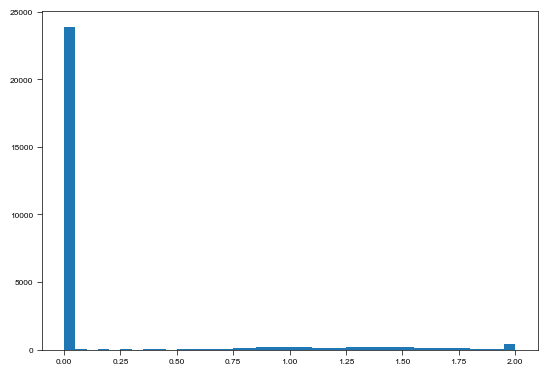

In [16]:
plt.hist(bivalent_ratios_list, bins=40)
plt.show()

In [17]:
def build_df(df_gene_noise, bivalent_ratios, h3k27me3_ratios, h3k4me3_ratios, coord_dict):
    
    genes_not_found = 0
    genes_found = 0
    
    genes = list(df_gene_noise.index)
    df_records = df_gene_noise.to_dict('records')
    ratio_records = []
    
    for i, record in enumerate(df_records):
    
        gene = genes[i]

        if gene not in bivalent_ratios:
            genes_not_found += 1
            continue
        else:
            genes_found += 1
            
        ratio_bivalent = bivalent_ratios[gene]
        ratio_h3k27me3 = h3k27me3_ratios[gene]
        ratio_h3k4me3 = h3k4me3_ratios[gene]

        coord_data = coord_dict[gene] | {'Ratio Bivalent': ratio_bivalent, 'Ratio H3K27me3': ratio_h3k27me3, 'Ratio H3K4me3': ratio_h3k4me3}
        
        ratio_records.append(coord_data | record)
    
    df_ratios = pd.DataFrame.from_records(ratio_records)
    
    print(f'{genes_not_found} genes not found')
    print(f'{genes_found} genes found')
    
    return df_ratios

In [18]:
ratio_cutoff = 0
intragenic_cutoff = 10000

df_ratios = build_df(df_gene_noise, bivalent_ratios, h3k27me3_ratios, h3k4me3_ratios, coord_dict)

conditions = [
                (df_ratios['Ratio Bivalent'] > ratio_cutoff),
                (df_ratios['Ratio H3K27me3'] > ratio_cutoff),
                (df_ratios['Ratio H3K4me3'] > ratio_cutoff),
                (df_ratios['Ratio Bivalent'] <= ratio_cutoff) | (df_ratios['Ratio H3K27me3'] <= ratio_cutoff) | (df_ratios['Ratio H3K4me3'] <= ratio_cutoff)
                ]

values = ['Bivalent', 'H3K27me3', 'H3K4me3', 'All Other Genes']
df_ratios['Class'] = np.select(conditions, values)

print(df_ratios.columns)

promoter_columns = ['chrom', 'start', 'end', 'length', 'strand',
       'gene', 'Ratio Bivalent', 'Ratio H3K27me3', 'Ratio H3K4me3',
       'MeanOverall_dko', 'Mean1_dko', 'Mean2_dko', 'MeanFC_dko',
       'MeanLog2FC_dko', 'ProbDiffMean_dko', 'ResultDiffMean_dko',
       'DispOverall_dko', 'Disp1_dko', 'Disp2_dko', 'DispFC_dko',
       'DispLog2FC_dko', 'ProbDiffDisp_dko', 'ResultDiffDisp_dko',
       'MeanOverall_tko', 'Mean1_tko', 'Mean2_tko', 'MeanFC_tko',
       'MeanLog2FC_tko', 'ProbDiffMean_tko', 'ResultDiffMean_tko',
       'DispOverall_tko', 'Disp1_tko', 'Disp2_tko', 'DispFC_tko',
       'DispLog2FC_tko', 'ProbDiffDisp_tko', 'ResultDiffDisp_tko', 'Class']

intragenic_columns = ['chrom', 'start_gene', 'end_gene', 'length', 'strand',
       'gene', 'Ratio Bivalent', 'Ratio H3K27me3', 'Ratio H3K4me3',
       'MeanOverall_dko', 'Mean1_dko', 'Mean2_dko', 'MeanFC_dko',
       'MeanLog2FC_dko', 'ProbDiffMean_dko', 'ResultDiffMean_dko',
       'DispOverall_dko', 'Disp1_dko', 'Disp2_dko', 'DispFC_dko',
       'DispLog2FC_dko', 'ProbDiffDisp_dko', 'ResultDiffDisp_dko',
       'MeanOverall_tko', 'Mean1_tko', 'Mean2_tko', 'MeanFC_tko',
       'MeanLog2FC_tko', 'ProbDiffMean_tko', 'ResultDiffMean_tko',
       'DispOverall_tko', 'Disp1_tko', 'Disp2_tko', 'DispFC_tko',
       'DispLog2FC_tko', 'ProbDiffDisp_tko', 'ResultDiffDisp_tko', 'Class']

df_promoter = df_ratios[promoter_columns]
df_intragenic = df_ratios[intragenic_columns]

print(df_promoter)

df_intragenic = df_intragenic[df_intragenic['start_gene'] < df_intragenic['end_gene']]

df_intragenic_limit = df_intragenic.copy()
df_intragenic_limit['start'] = np.where(
    df_intragenic_limit['strand'] == '+',
    df_intragenic_limit['start_gene'],  # + strand: start unchanged
    np.maximum(df_intragenic_limit['start_gene'], df_intragenic_limit['end_gene'] - intragenic_cutoff)  # - strand: limit start
)
df_intragenic_limit['end'] = np.where(
    df_intragenic_limit['strand'] == '+',
    np.minimum(df_intragenic_limit['end_gene'], df_intragenic_limit['start_gene'] + intragenic_cutoff),  # + strand: limit end
    df_intragenic_limit['end_gene']  # - strand: end unchanged
)
df_intragenic_limit = df_intragenic_limit[promoter_columns]

df_intragenic_limit = df_intragenic_limit[df_intragenic_limit['start'] < df_intragenic_limit['end']]

print(df_intragenic_limit)

7935 genes not found
15870 genes found
Index(['chrom', 'start', 'end', 'start_gene', 'end_gene', 'length', 'strand',
       'gene', 'Ratio Bivalent', 'Ratio H3K27me3', 'Ratio H3K4me3',
       'MeanOverall_dko', 'Mean1_dko', 'Mean2_dko', 'MeanFC_dko',
       'MeanLog2FC_dko', 'ProbDiffMean_dko', 'ResultDiffMean_dko',
       'DispOverall_dko', 'Disp1_dko', 'Disp2_dko', 'DispFC_dko',
       'DispLog2FC_dko', 'ProbDiffDisp_dko', 'ResultDiffDisp_dko',
       'MeanOverall_tko', 'Mean1_tko', 'Mean2_tko', 'MeanFC_tko',
       'MeanLog2FC_tko', 'ProbDiffMean_tko', 'ResultDiffMean_tko',
       'DispOverall_tko', 'Disp1_tko', 'Disp2_tko', 'DispFC_tko',
       'DispLog2FC_tko', 'ProbDiffDisp_tko', 'ResultDiffDisp_tko', 'Class'],
      dtype='object')
       chrom      start        end  length strand      gene  Ratio Bivalent  \
0      chr19   58862858   58866858    8309      -      A1BG           0.000   
1      chr19   58861336   58865336    3213      +  A1BG-AS1           0.000   
2      chr12  

In [19]:
# Write intersected files

path_noise_dir = 'basics/bed'

os.makedirs(path_noise_dir, exist_ok=True)

intersection_type = 'promoter'
path_bed = os.path.join(path_noise_dir, f'{intersection_type}_ratio{ratio_cutoff}_{extension}.bed')
df_promoter.to_csv(path_bed, sep='\t', index=False, header=False)

intersection_type = 'intragenic'
path_bed = os.path.join(path_noise_dir, f'{intersection_type}_ratio{ratio_cutoff}_{extension}.bed')
df_intragenic.to_csv(path_bed, sep='\t', index=False, header=False)

intersection_type = 'intragenic_limit'
path_bed = os.path.join(path_noise_dir, f'{intersection_type}_ratio{ratio_cutoff}_{extension}.bed')
df_intragenic_limit.to_csv(path_bed, sep='\t', index=False, header=False)

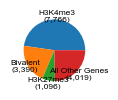

In [17]:
fig, ax = plt.subplots()
fig.set_size_inches(1, 1)

gene_counts = []
order = ['H3K4me3', 'Bivalent', 'H3K27me3', 'All Other Genes']
for value in order:
    
    df_filter = df_ratios.loc[df_ratios['Class'] == value]
    gene_counts.append(len(df_filter.index))

y = np.array(gene_counts)

labels = [f'{value}\n({gene_counts[i]:,})' for i, value in enumerate(order)]
#labels = [f'Hypo ({dmr_counts[0]})', f'Hyper ({dmr_counts[1]})', f'No ({dmr_counts[2]})']

ax.pie(y, labels=labels, textprops={'ha':'center'})
plt.savefig('figures/gene_classes.svg')

In [40]:
def plot_violin(df, title, x, y, hue, hue_order, path_out_dir, width_height=[1.5,1.5]):
    
    fig, ax = plt.subplots()
    sns.violinplot(data=df, x=x, y=hue, hue=hue, ax=ax, hue_order=order, order=order)
    
    fig.set_size_inches(width_height[0], width_height[1])
    ax.set_xlabel(f'{x} {title}')
    ax.set_xlim([-7.5, 7.5])

    # Calculate overall mean and std for significance testing
    overall_data = df[x].dropna()
    overall_mean = overall_data.mean()
    
    # Add mean values and significance stars
    for i, category in enumerate(hue_order):
        # Get data for this category
        category_data = df[df[hue] == category][x].dropna()
        
        if len(category_data) > 0:
            mean_val = category_data.mean()
            
            # Perform t-test against overall distribution
            if len(category_data) > 1:
                t_stat, p_value = stats.ttest_ind(category_data, overall_data)
                
                # Determine significance stars
                if p_value < 0.001:
                    stars = '***'
                elif p_value < 0.01:
                    stars = '**'
                elif p_value < 0.05:
                    stars = '*'
                else:
                    stars = ''
            else:
                stars = ''
            
            # Create annotation text
            text = f'{mean_val:.3f}{stars}'
            
            # Position text on right side of plot, at the violin's height
            ax.text(-7.3, i - 0.2, text, va='center', ha='left', fontsize=8)
    
    filename = title.replace('/', '-') + x.replace(' ', '_').lower() + '_violin.svg'
    
    path_svg = os.path.join(path_out_dir, filename)
    plt.savefig(path_svg, format="svg", bbox_inches="tight")

16271
Number of valid TKO genes: 10027
Number of valid DKO genes: 12150
16271
mean TKO H3K4me3: -0.07495633490435263
mean DKO H3K4me3: -0.0644536303851832
ratio of changing H3K4me3 mean TKO genes: 0.019381946326917865
ratio of changing H3K4me3 mean DKO genes: 0.006969575123978019
ratio of changing H3K4me3 dispersion TKO genes: 0.017981843575418995
ratio of changing H3K4me3 dispersion DKO genes: 0.0001514692517418964

mean TKO Bivalent: -0.036715296495956874
mean DKO Bivalent: -0.19188250484183345
ratio of changing Bivalent mean TKO genes: 0.19165870741801974
ratio of changing Bivalent mean DKO genes: 0.05379746835443038
ratio of changing Bivalent dispersion TKO genes: 0.1299000768639508
ratio of changing Bivalent dispersion DKO genes: 0.01860009789525208

mean TKO H3K27me3: -0.1865079365079365
mean DKO H3K27me3: -0.03121811100292113
ratio of changing H3K27me3 mean TKO genes: 0.12367149758454106
ratio of changing H3K27me3 mean DKO genes: 0.039122137404580155
ratio of changing H3K27me3 d

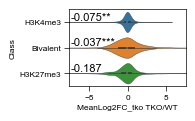

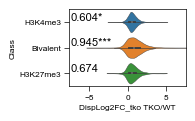

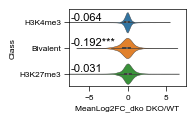

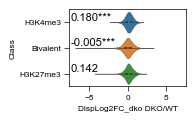

In [41]:
# scatterplot
order = ['H3K4me3', 'Bivalent', 'H3K27me3']
hue_order = ['H3K4me3', 'Bivalent', 'H3K27me3']

pairs = [
    ("H3K4me3", "Bivalent"),
    ("H3K4me3", "H3K27me3")
]

hue = 'Class'

df_tko_valid = df_ratios.loc[(df_ratios['ResultDiffDisp_tko'] != 'ExcludedLowESS') & (df_ratios['ResultDiffDisp_tko'] != 'ExcludedFromTesting')]
df_dko_valid = df_ratios.loc[(df_ratios['ResultDiffDisp_dko'] != 'ExcludedLowESS') & (df_ratios['ResultDiffDisp_dko'] != 'ExcludedFromTesting')]
print(len(df_ratios))
print('Number of valid TKO genes:', len(df_tko_valid))
print('Number of valid DKO genes:', len(df_dko_valid))

width_height = [1.5,1]
fc_limit = 2

print(len(df_ratios.index))

for item in hue_order:
    
    df_filt = df_ratios.loc[df_ratios['Class'] == item]

    df_tko_mean = df_filt.loc[df_filt['ResultDiffMean_tko'] != 'ExcludedLowESS']
    df_tko_disp = df_filt.loc[(df_filt['ResultDiffDisp_tko'] != 'ExcludedLowESS') & (df_filt['ResultDiffDisp_tko'] != 'ExcludedFromTesting')]
    df_dko_mean = df_filt.loc[df_filt['ResultDiffMean_dko'] != 'ExcludedLowESS']
    df_dko_disp = df_filt.loc[(df_filt['ResultDiffDisp_dko'] != 'ExcludedLowESS') & (df_filt['ResultDiffDisp_dko'] != 'ExcludedFromTesting')]
    
    df_tko_mean_increase = df_tko_mean.loc[df_tko_mean['MeanLog2FC_tko'] > fc_limit]
    df_dko_mean_increase = df_dko_mean.loc[df_dko_mean['MeanLog2FC_dko'] > fc_limit]

    df_tko_disp_increase = df_tko_disp.loc[df_tko_disp['DispLog2FC_tko'] > fc_limit]
    df_dko_disp_increase = df_dko_disp.loc[df_dko_disp['DispLog2FC_dko'] > fc_limit]

    df_tko_mean_decrease = df_tko_mean.loc[df_tko_mean['MeanLog2FC_tko'] < -fc_limit]
    df_dko_mean_decrease = df_dko_mean.loc[df_dko_mean['MeanLog2FC_dko'] < -fc_limit]

    df_tko_disp_decrease = df_tko_disp.loc[df_tko_disp['DispLog2FC_tko'] < -fc_limit]
    df_dko_disp_decrease = df_dko_disp.loc[df_dko_disp['DispLog2FC_dko'] < -fc_limit]

    num_change_tko_mean = len(df_tko_mean_increase.index) + len(df_tko_mean_decrease.index)
    num_change_dko_mean = len(df_dko_mean_increase.index) + len(df_dko_mean_decrease.index)
    
    num_change_tko_disp = len(df_tko_disp_increase.index) + len(df_tko_disp_decrease.index)
    num_change_dko_disp = len(df_dko_disp_increase.index) + len(df_dko_disp_decrease.index)

    mean_mean_tko = np.mean(df_tko_mean['MeanLog2FC_tko'])
    mean_mean_dko = np.mean(df_dko_mean['MeanLog2FC_dko'])

    print(f'mean TKO {item}: {mean_mean_tko}')
    print(f'mean DKO {item}: {mean_mean_dko}')

    print(f'ratio of changing {item} mean TKO genes: {num_change_tko_mean / len(df_tko_mean.index)}')
    print(f'ratio of changing {item} mean DKO genes: {num_change_dko_mean / len(df_dko_mean.index)}')

    print(f'ratio of changing {item} dispersion TKO genes: {num_change_tko_disp / len(df_tko_disp.index)}')
    print(f'ratio of changing {item} dispersion DKO genes: {num_change_dko_disp / len(df_dko_disp.index)}')

    print()

#df_sample = df_ratios.sample(n=5000)
df_sample = df_ratios

df_tko_mean = df_sample.loc[df_sample['ResultDiffMean_tko'] != 'ExcludedLowESS']
x = 'MeanLog2FC_tko'
y = 'ProbDiffMean_tko'
print(df_tko_mean.groupby(by='Class')[x].mean())
plot_violin(df_tko_mean, 'TKO/WT', x, y, hue, hue_order, path_out_dir, width_height=width_height)

df_tko_disp = df_sample.loc[(df_sample['ResultDiffDisp_tko'] != 'ExcludedLowESS') & (df_sample['ResultDiffDisp_tko'] != 'ExcludedFromTesting')]
x = 'DispLog2FC_tko'
y = 'ProbDiffDisp_tko'
print(df_tko_disp.groupby(by='Class')[x].mean())
plot_violin(df_tko_disp, 'TKO/WT', x, y, hue, hue_order, path_out_dir, width_height=width_height)

df_dko_mean = df_sample.loc[df_sample['ResultDiffMean_dko'] != 'ExcludedLowESS']
x = 'MeanLog2FC_dko'
y = 'ProbDiffMean_dko'
print(df_dko_mean.groupby(by='Class')[x].mean())
plot_violin(df_dko_mean, 'DKO/WT', x, y, hue, hue_order, path_out_dir, width_height=width_height)

df_dko_disp = df_sample.loc[(df_sample['ResultDiffDisp_dko'] != 'ExcludedLowESS') & (df_sample['ResultDiffDisp_dko'] != 'ExcludedFromTesting')]
x = 'DispLog2FC_dko'
y = 'ProbDiffDisp_dko'
print(df_dko_disp.groupby(by='Class')[x].mean())
plot_violin(df_dko_disp, 'DKO/WT', x, y, hue, hue_order, path_out_dir, width_height=width_height)